In [1]:
!gdown --id 17hm4OL74_zRcWT2kwwqJyrALCEIinPcM

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=17hm4OL74_zRcWT2kwwqJyrALCEIinPcM
To: /content/Training Data.csv
100% 20.1M/20.1M [00:00<00:00, 28.3MB/s]


In [3]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.6 MB/s eta 0:00:00


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy import stats
from scipy.stats import f_oneway
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import recall_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, PassiveAggressiveClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings("ignore")

In [5]:
from matplotlib import rcParams

rcParams['figure.figsize'] = 12, 4
rcParams['lines.linewidth'] = 3
rcParams['xtick.labelsize'] = 'x-large'
rcParams['ytick.labelsize'] = 'x-large'
colors = ['teal', 'darkorange', 'darkblue','maroon']

In [2]:
df = pd.read_csv('Loan_Predict.csv')
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


# Business Understanding

1. Problem dari dataset
* Tingginya angka pinjaman
* Tingginya angka gagal bayar
* Staff yang terbatas

2. Goal yang ingin dicapai
* Meningkatkan akurasi dalam persetujuan pinjaman
* Meningkatkan efisiensi dalam mengevaluasi pinjaman untuk mendukung staf yang terbatas

3. Objective yang sesuai dengan goal
* Mengembangkan model untuk memprediksi pinjaman yang beresiko
* Mengembangkan model untuk menghindari bias dan mendukung keputusan pemberian pinjaman yang akurat

4. Business metrics untuk mengukur ketercapaian Objective
* Default Reduction Rate: Persentase penurunan pinjaman yang gagal bayar
* Approval Rate Optimization: Mengoptimalkan persetujuan pinjaman dan meminimalkan risiko
* Net Income Increase: Meningkatkan pendapatan bersih dengan mempercepat proses persetujuan pinjaman agar meningkatkan penanganan aplikasi yang lebih banyak
* Non-Performing Loan (NPL) Reduction Rate: Meningkatkan akurasi penilaian pinjaman beresiko

# Exploratory Data Analysis

Penjelasan fitur:
1. **Id**: Identifikasi unik untuk setiap peminjam.  
2. **Income**: Pendapatan tahunan peminjam (nilai numerik dalam satuan mata uang).  
3. **Age**: Usia peminjam dalam tahun.  
4. **Experience**: Jumlah tahun pengalaman kerja profesional.  
5. **Married/Single**: Status pernikahan (Menikah atau Lajang).  
6. **House_Ownership**: Jenis kepemilikan rumah (Milik, Sewa, atau Tidak Sewa dan Tidak Milik).  
7. **Car_Ownership**: Apakah peminjam memiliki mobil (Ya atau Tidak).  
8. **Profession**: Pekerjaan atau profesi peminjam.  
9. **CITY**: Kota tempat tinggal peminjam.  
10. **STATE**: Provinsi tempat tinggal peminjam.  
11. **CURRENT_JOB_YRS**: Jumlah tahun bekerja di pekerjaan saat ini.  
12. **CURRENT_HOUSE_YRS**: Jumlah tahun tinggal di rumah saat ini.  
13. **Risk_Flag**: Variabel target – bernilai **1** jika peminjam berisiko gagal bayar, dan **0** jika tergolong risiko rendah.

In [8]:
df['Id'] = df['Id'].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  object
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(6), object(7)
memory usage: 25.0+ MB


In [9]:
cats= ['Id','Married/Single','House_Ownership','Car_Ownership','Profession','CITY','STATE']
nums=['Income','Age','Experience','CURRENT_JOB_YRS','CURRENT_HOUSE_YRS','Risk_Flag']

# General Info

In [10]:
df.describe()

,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000
mean,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000
std,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438
min,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000
50%,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000


In [11]:
df[cats].describe()

,Id,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE
count,252000,252000,252000,252000,252000,252000,252000
unique,252000,2,3,2,51,317,29
top,251961,single,rented,no,Physician,Vijayanagaram,Uttar_Pradesh
freq,1,226272,231898,176000,5957,1259,28400


# Checking Empty and duplicated data

In [12]:
df.isnull().sum()

,0
Id,0
Income,0
Age,0
Experience,0
Married/Single,0
House_Ownership,0
Car_Ownership,0
Profession,0
CITY,0
STATE,0


**Data Insight**

1. Kolom Id memiliki tipe data yang tidak tepat (Integer), sehingga diubah menjadi string
2. Total data dari dataset adalah 252.000 dan tidak ada data yang hilang atau duplikat

# Univariate Analysis

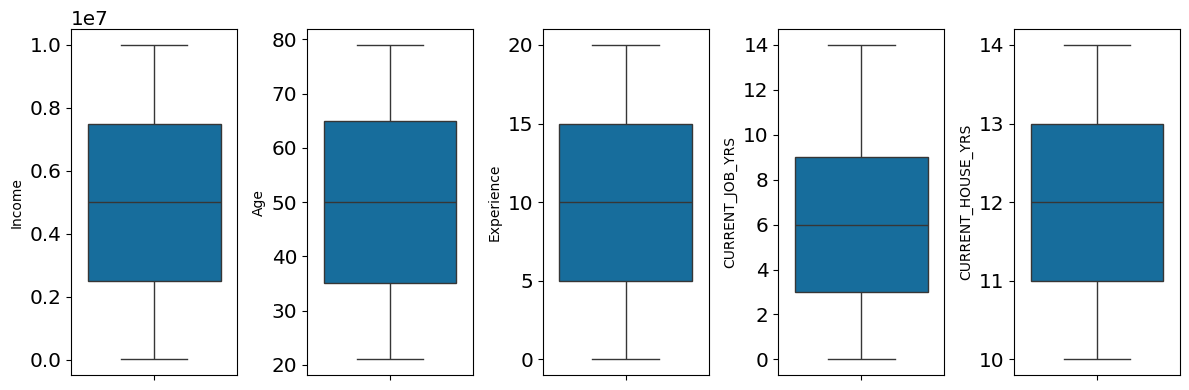

In [13]:
for i in range(0, len(nums[:-1])):
    plt.subplot(1, len(nums[:-1]), i+1)
    sns.boxplot(y=df[nums[:-1][i]], orient='v', palette='colorblind')
    plt.tight_layout()

**Data Insight**

Kolom Income, Age, Experience, CURRENT_JOB_YRS, dan CURRENT_HOUSE_YRS tidak memiliki outlier. Ini menunjukkan data terdistribusi dengan baik tanpa nilai ekstrem

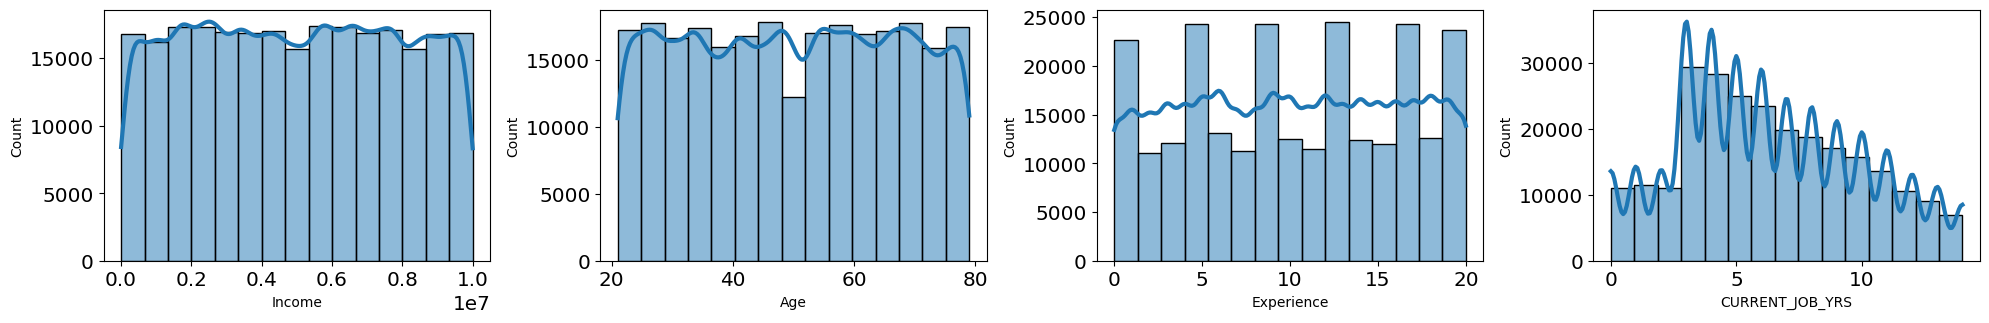

In [14]:
plt.figure(figsize=(20,6))
for i in range(0, len(nums[:-2])):
    plt.subplot(2, len(nums[:-2]), i+1)
    sns.histplot(df[nums[:-2][i]], bins=15, kde=True)
    plt.tight_layout()

**Data Insight**
1. Kolom Income, Age, dan Experience memiliki distribusi normal
2. Kolom CURRENT_JOB_YRS memiliki distribusi positive skewness

<Axes: xlabel='CURRENT_HOUSE_YRS', ylabel='count'>

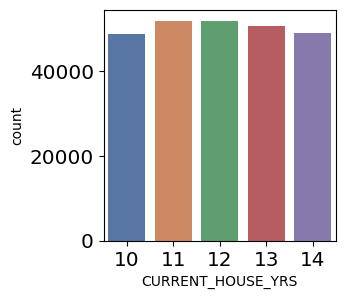

In [ ]:
plt.figure(figsize=(3,3))
sns.countplot(x=df['CURRENT_HOUSE_YRS'], palette='deep')

**Data Insight**

Lebih dari 40.000 peminjam sudah tinggal di rumahnya saat ini untuk rentang 10-14 tahun, dimana jumlah peminjam untuk setiap kategori tahun cukup seimbang

In [ ]:
def compute_distribution(df, col):

    """
    Utility function to check data distribution for numerical features.

    mean >  median : Positive (Right) Skewed
    mean <  median : Negative (Left) Skewed
    mean == median : Normal

    skew in range (-0.5, 0.5) = approximately symmetrical (Normal distribution)
    skew in range (-1, 1) = moderately skewed
    skew > 1 or skew < -1 = highly skewed

    kurtosis > 3 : Leptokurtic
    kurtosis == 3: Mesokurtic
    kurtosis < 3: Platykurtic

    :param df: pandas dataframe
    :param col: selected numerical feature (string)
    :return: type of distribution (string)
    """

    mean = df[col].mean()
    median = df[col].median()

    skew_score = df[col].skew()
    kurtosis_score = df[col].kurtosis()

    if (skew_score > -0.5) and (skew_score < 0.5):
        skewness = 'Approximately Symmetric'
    elif (skew_score > -1) and (skew_score < 1):
        skewness = 'Moderately Skewed'
    else:
        skewness = 'Highly Skewed'

    if kurtosis_score > 3:
        kurtosis_flag = 'Leptokurtic'
    elif kurtosis_score == 3:
        kurtosis_flag = 'Mesokurtic'
    else:
        kurtosis_flag = 'Platykurtic'

    if mean < median:

        print(f'{col} data distribution: Left Skewed Distribution')
        print(f'Skewness score: {df[col].skew():.2f} [{skewness}]')
        print('--------------------------------------')

    elif mean > median:

        print(f'{col} data distribution: Right Skewed Distribution')
        print(f'Skewness score: {df[col].skew():.2f} [{skewness}]')
        print('--------------------------------------')

    else:

        print(f'{col} data distribution: Normal Distribution')
        print(f'Skewness score: {df[col].skew():.2f} [{skewness}]')
        print('--------------------------------------')

In [ ]:
for i in nums[:-2]:
    compute_distribution(df, col=i)

Income data distribution: Left Skewed Distribution
Skewness score: 0.01 [Approximately Symmetric]
--------------------------------------
Age data distribution: Left Skewed Distribution
Skewness score: -0.01 [Approximately Symmetric]
--------------------------------------
Experience data distribution: Right Skewed Distribution
Skewness score: -0.01 [Approximately Symmetric]
--------------------------------------
CURRENT_JOB_YRS data distribution: Right Skewed Distribution
Skewness score: 0.27 [Approximately Symmetric]
--------------------------------------


**Data Insight**

  Distribusi data mendekati distribusi normal

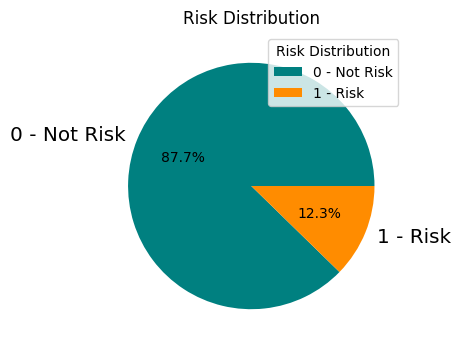

In [ ]:
# Define mapping for Risk_Flag
risk_mapping = {0: "0 - Not Risk", 1: "1 - Risk"}

# Create the pie chart
plt.pie(df['Risk_Flag'].value_counts().values,
        labels=[risk_mapping[label] for label in df['Risk_Flag'].value_counts().index],
        autopct='%0.1f%%', colors=colors)

plt.title('Risk Distribution')

# Add a legend with both numbers and descriptions
plt.legend(title='Risk Distribution',
           labels=["0 - Not Risk", "1 - Risk"],
           loc="upper right")

**Data Insight**

Mayoritas 87,7% peminjam diklasifikasikan sebagai "Tidak Beresiko", sementara hanya 12,3% yang termasuk dalam kategori "Beresiko". Hal ini penting untuk dipertimbangkan dalam model prediksi, karena model bisa bias terhadap kelas mayoritas

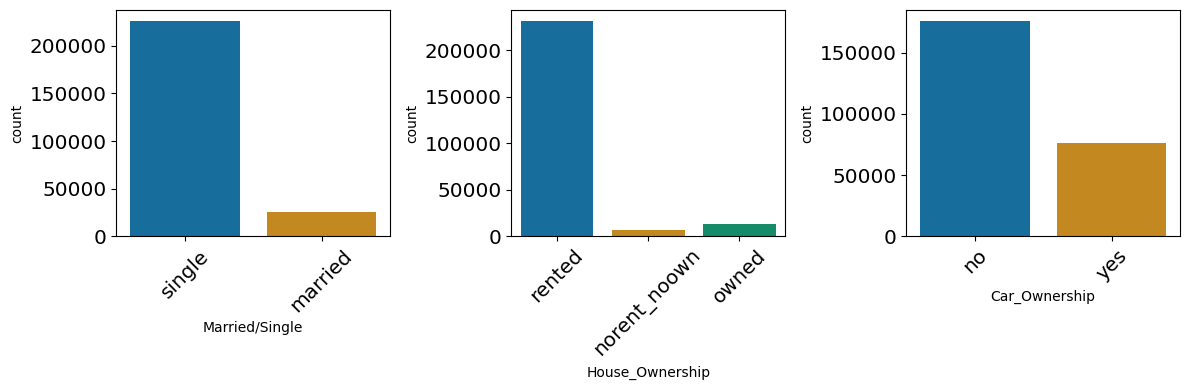

In [ ]:
for i in range(0, len(cats[1:4])):
    plt.subplot(1, len(cats[1:4]), i+1)
    sns.countplot(x=df[cats[1:4][i]], palette='colorblind')
    plt.tight_layout()
    plt.xticks(rotation=45)

**Data Insight**

Mayoritas peminjam adalah single, menyewa rumah, dan tidak memiliki mobil

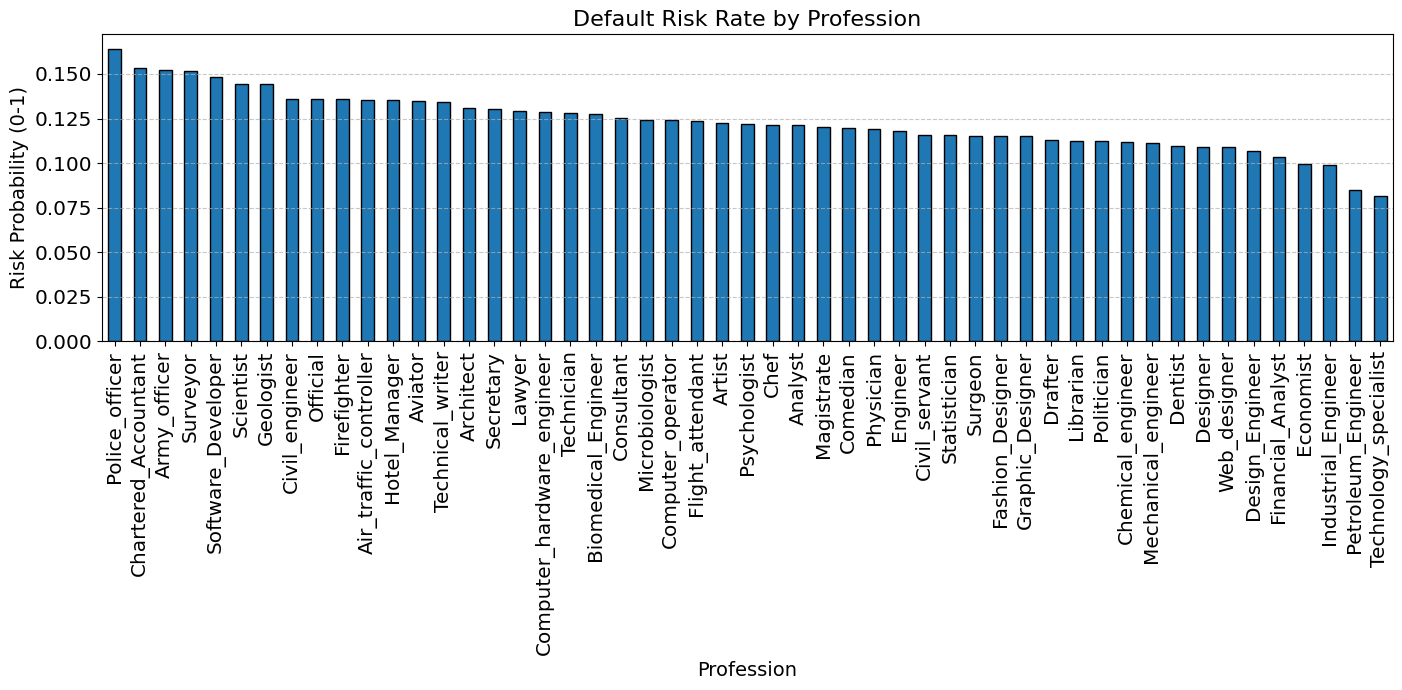

In [17]:
risk_by_profession = df.groupby('Profession')['Risk_Flag'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,7))
risk_by_profession.plot(kind='bar', edgecolor='black')
plt.title('Default Risk Rate by Profession', fontsize=16)
plt.xlabel('Profession', fontsize=14)
plt.ylabel('Risk Probability (0-1)', fontsize=14)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Data Insight**  
Police officer, Chartered accountant, Education administrator, Army officer → Top professions with the highest risk probability.

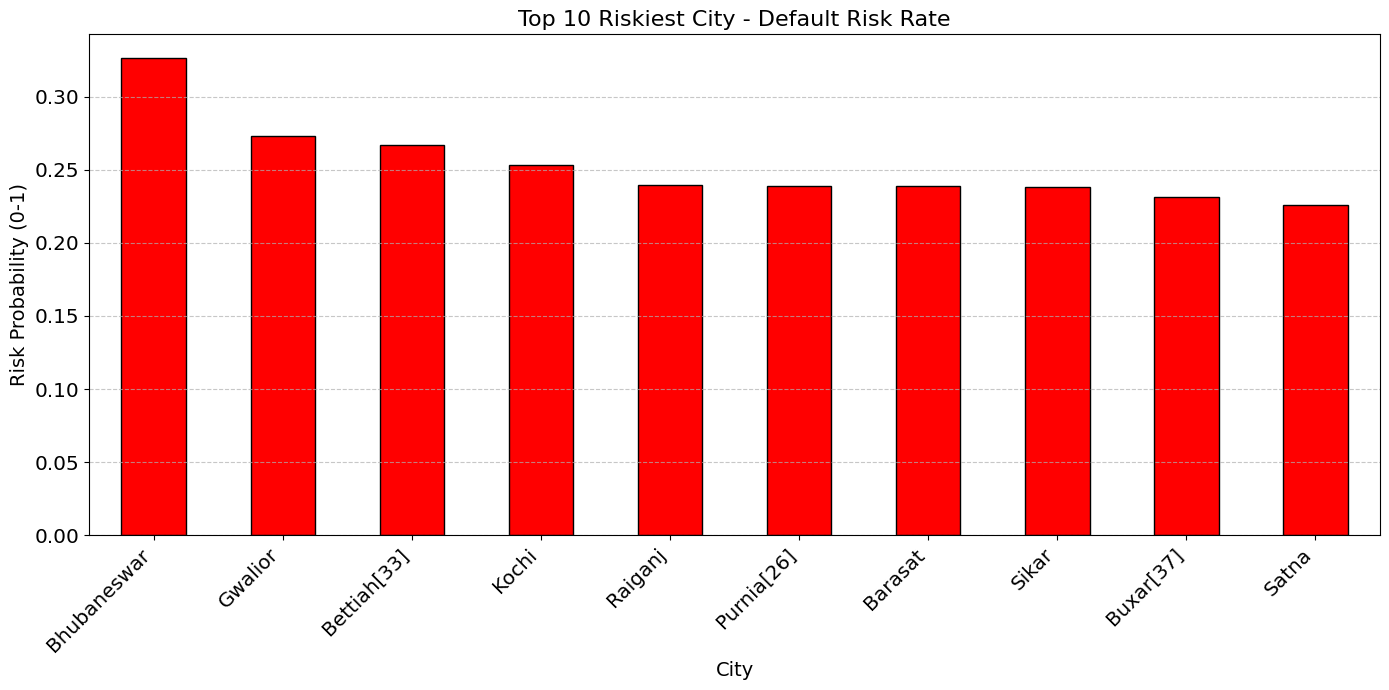

In [21]:
risk_by_city = df.groupby('CITY')['Risk_Flag'].mean().sort_values(ascending=False)

top_risky = risk_by_city.head(10)

plt.figure(figsize=(14,7))
top_risky.plot(kind='bar', color='red', edgecolor='black')
plt.title('Top 10 Riskiest City - Default Risk Rate', fontsize=16)
plt.xlabel('City', fontsize=14)
plt.ylabel('Risk Probability (0-1)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Data Insight**  
Bhubaneswar, Gwalior, and Bettiah are the top three cities with the highest default risk probabilities, exceeding 25%.

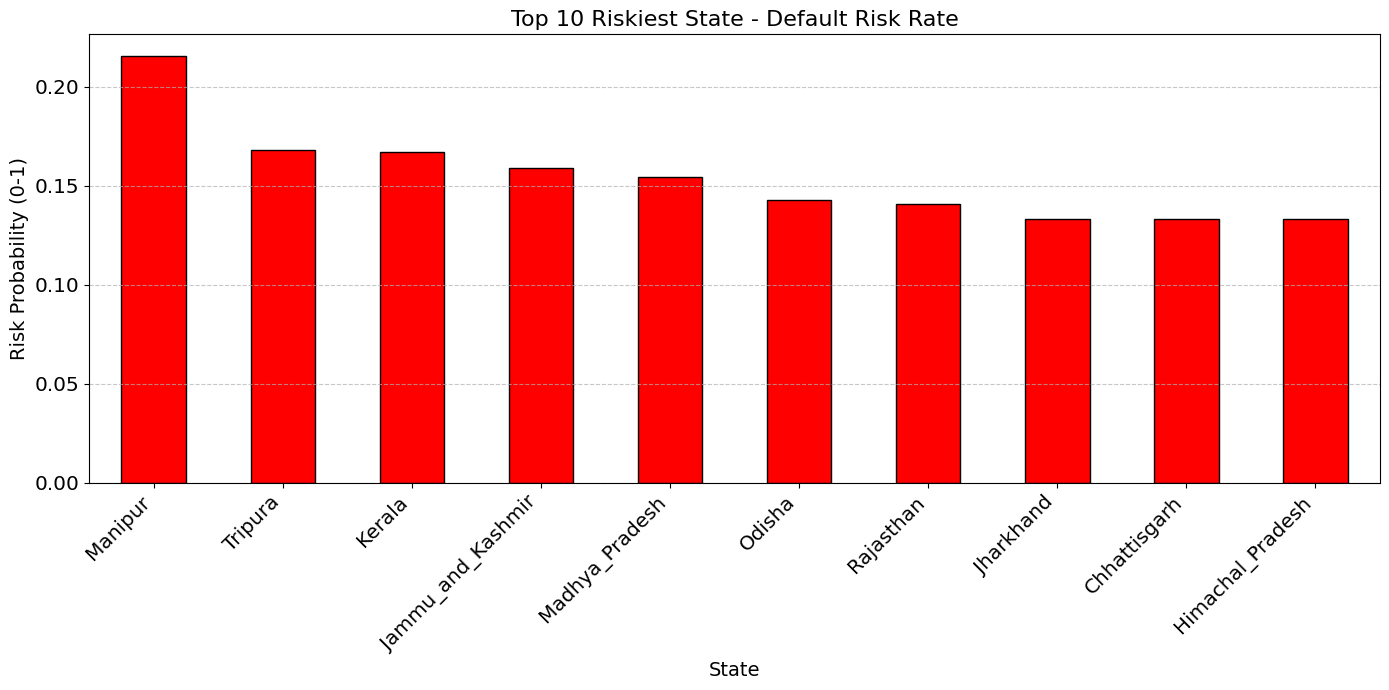

In [22]:
risk_by_state = df.groupby('STATE')['Risk_Flag'].mean().sort_values(ascending=False)

top_risky_state = risk_by_state.head(10)

plt.figure(figsize=(14,7))
top_risky_state.plot(kind='bar', color='red', edgecolor='black')
plt.title('Top 10 Riskiest State - Default Risk Rate', fontsize=16)
plt.xlabel('State', fontsize=14)
plt.ylabel('Risk Probability (0-1)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Data Insight**  
Manipur, Tripura, and Kerala as the top three states with the highest default risk probabilities, with Manipur standing out at over 21% risk.

# Multivariate Analysis

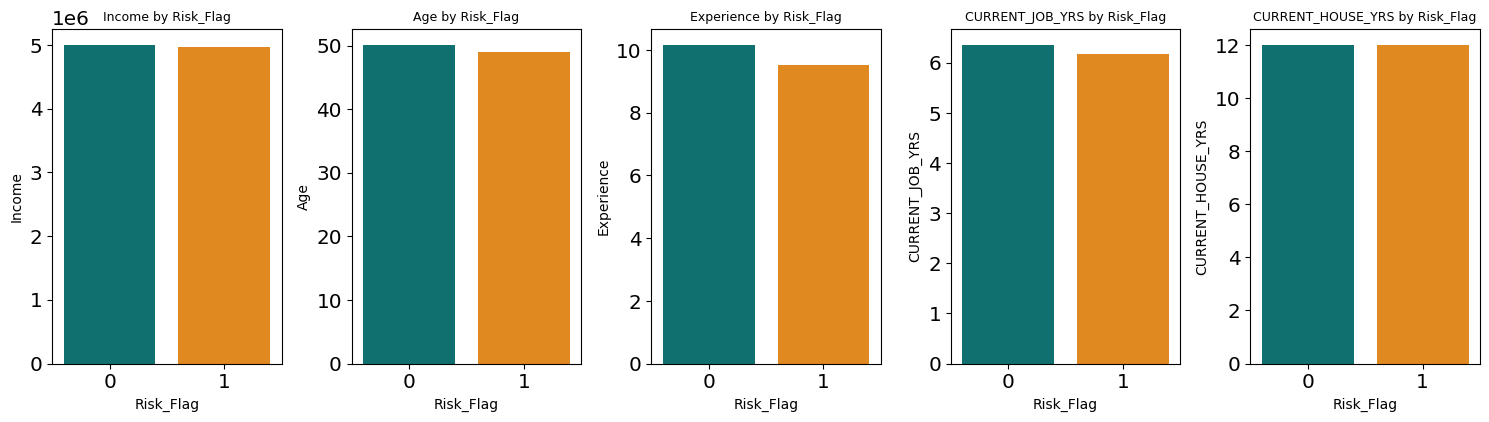

In [ ]:
plt.figure(figsize=(15, 8))
for i in range(0, len(nums[:-1])):
    plt.subplot(2, len(nums[:-1]), i+1)
    sns.barplot(x="Risk_Flag", y=nums[i], data=df, estimator=np.mean, errorbar=None, palette=colors)
    plt.title(f'{nums[i]} by Risk_Flag', fontsize=9)
    plt.ylabel(nums[i])
    plt.xticks(rotation = 0)
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

**Data Insight**

Semua variabel (Income, Age, Experience, CURRENT_JOB_YRS, CURRENT_HOUSE_YRS) tidak menunjukkan perbedaan signifikan antara kelompok Risk dan Not Risk, sehingga bukan menjadi indikator kuat dalam mempengaruhi resiko

(array([  0.,  20.,  40.,  60.,  80., 100., 120.]),
 [Text(0.0, 0, '0'),
  Text(20.0, 0, '20'),
  Text(40.0, 0, '40'),
  Text(60.0, 0, '60'),
  Text(80.0, 0, '80'),
  Text(100.0, 0, '100'),
  Text(120.0, 0, '120')])

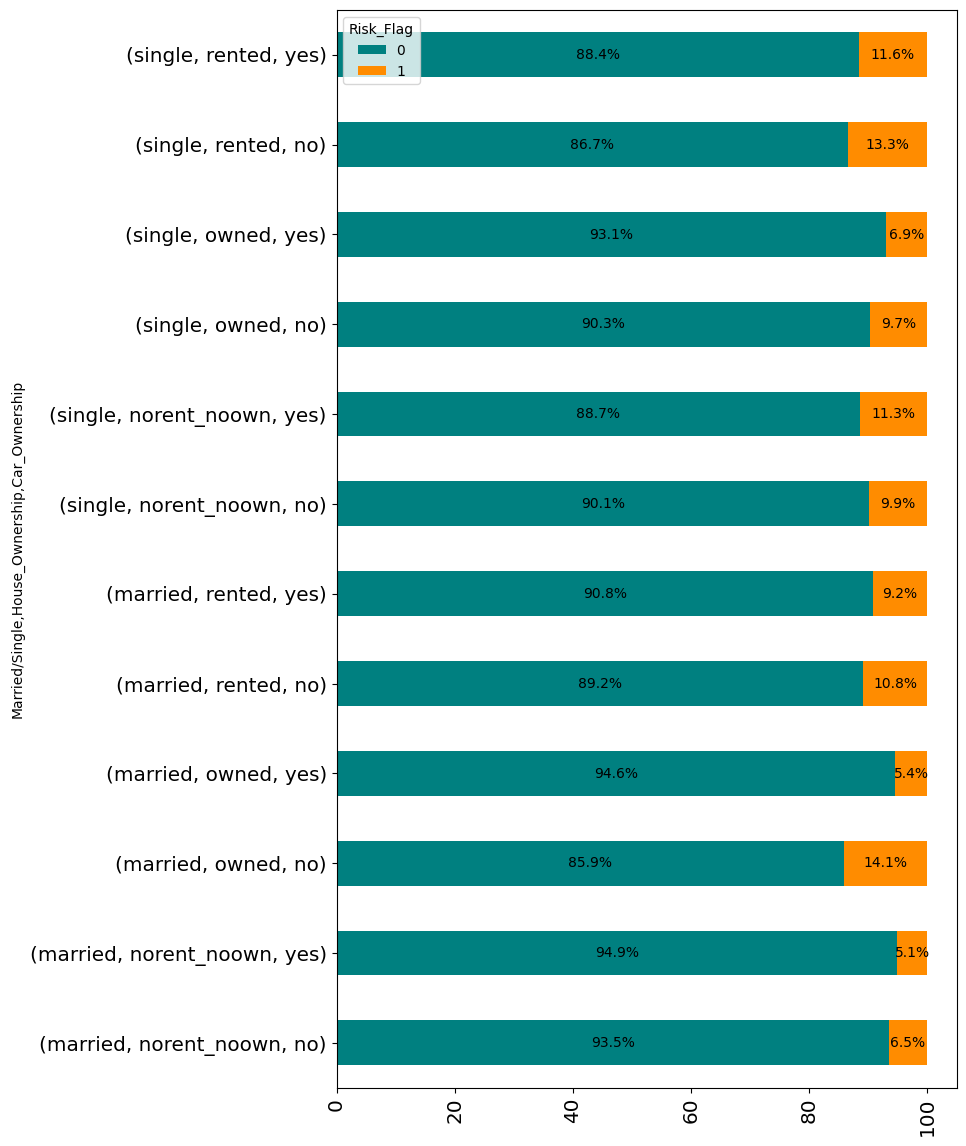

In [ ]:
dfi = df.groupby(['Married/Single','House_Ownership','Car_Ownership','Risk_Flag'])['Id'].count().reset_index().rename(columns={'Id':'Total Customer'})
dfi['Percentage']=dfi.groupby(['Married/Single','House_Ownership','Car_Ownership'])['Total Customer'].transform(lambda x: round((x / x.sum()) * 100, 2))
dfpiv= dfi.pivot_table(index=['Married/Single','House_Ownership','Car_Ownership'], columns='Risk_Flag', values='Percentage')
av = dfpiv.plot(kind="barh", stacked=True, figsize=(8,14), color=colors)
for bars in av.containers:
    av.bar_label(bars, fmt="%.1f%%", label_type="center", color="black")
plt.xticks(rotation = 90)

**Data Insight**

  Peminjam dengan resiko tertinggi merupakan seorang yg menikah, memiliki rumah namun tidak memiliki mobil.

## Chi Square Test

In [ ]:
def chi_squared_test(df, cat1, cat2):

    """
    Conducting a Chi-Squared Hypothesis Test.
    :param df:
    :param cat1:
    :param cat2:
    :return:
    """
    print(f'{cat1} and {cat2}')
    contingency_table = pd.crosstab(df[cat1], df[cat2])
    res = stats.chi2_contingency(contingency_table)

    # interpret p-value
    alpha = 0.05
    print("p value is " + str(res.pvalue))
    if res.pvalue <= alpha:
        print(f"There is a significant relationship (dependency) between {cat1} and {cat2}")
    else:
        print(f'{cat1} and {cat2} are independent (no significant relationship).')
    print('--------------------------------------')

In [ ]:
for i in cats[1:]:
  chi_squared_test(df, cat1=i, cat2='Risk_Flag')

Married/Single and Risk_Flag
p value is 3.773053705715196e-26
There is a significant relationship (dependency) between Married/Single and Risk_Flag
--------------------------------------
House_Ownership and Risk_Flag
p value is 1.8381930028370595e-40
There is a significant relationship (dependency) between House_Ownership and Risk_Flag
--------------------------------------
Car_Ownership and Risk_Flag
p value is 1.7350853850183746e-33
There is a significant relationship (dependency) between Car_Ownership and Risk_Flag
--------------------------------------
Profession and Risk_Flag
p value is 5.108641602000937e-98
There is a significant relationship (dependency) between Profession and Risk_Flag
--------------------------------------
CITY and Risk_Flag
p value is 0.0
There is a significant relationship (dependency) between CITY and Risk_Flag
--------------------------------------
STATE and Risk_Flag
p value is 2.0057472384130266e-136
There is a significant relationship (dependency) betwe

**Data Insight**

  Semua features kategorikal memiliki korelasi dengan column target Risk_flag.

# Anova

In [ ]:
def compute_anova(df, nums, cats):
    print(f'Anova : {nums} and {cats}')

    # Example data
    unique_groups = df[cats].unique()

    # Create a list to store numerical values for each group
    groups = [df[df[cats] == group][nums] for group in unique_groups]

    # ANOVA test
    f_stat, p_value = f_oneway(*groups)

    print(f"F-statistic: {f_stat}, P-value: {p_value}")

    if p_value <= 0.05:
        print(f"{nums} among {cats}'s {len(unique_groups)} categories are significantly different")
    else:
        print(f"{nums} among {cats}'s {len(unique_groups)} categories are not significantly difference")
    print('--------------------------------------')

In [ ]:
for i in nums[:-1]:
  compute_anova(df,nums=i,cats='Risk_Flag')

Anova : Income and Risk_Flag
F-statistic: 2.4079446287996715, P-value: 0.1207220319583281
Income among Risk_Flag's 2 categories are not significantly difference
--------------------------------------
Anova : Age and Risk_Flag
F-statistic: 119.91850679948466, P-value: 6.687623647499306e-28
Age among Risk_Flag's 2 categories are significantly different
--------------------------------------
Anova : Experience and Risk_Flag
F-statistic: 300.69230651920316, P-value: 2.5475634865752383e-67
Experience among Risk_Flag's 2 categories are significantly different
--------------------------------------
Anova : CURRENT_JOB_YRS and Risk_Flag
F-statistic: 72.34852624927743, P-value: 1.813221223267855e-17
CURRENT_JOB_YRS among Risk_Flag's 2 categories are significantly different
--------------------------------------
Anova : CURRENT_HOUSE_YRS and Risk_Flag
F-statistic: 4.823851147277152, P-value: 0.028069472774381213
CURRENT_HOUSE_YRS among Risk_Flag's 2 categories are significantly different
-------

**Data Insight**

  Income yang biasanya merupakan acuan utama penentu Risk_flag ternyata tidak memiliki korelasi dengan Risk_flag pada kasus ini. Feature ini dapat di drop dan dilakukan feature engineering berupa binning untuk tetap menggunakan informasinya.

<Axes: >

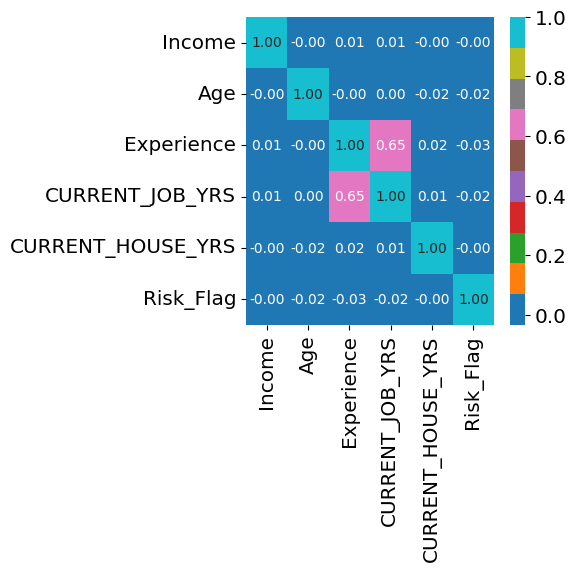

In [ ]:
plt.figure(figsize=(4, 4))
sns.heatmap(df.select_dtypes(["float64", "int64", "boolean"]).corr(), cmap='tab10', annot=True, fmt='.2f')

# Feature Engineering(New Feature)

### 1. Income Level

In [ ]:
# Define percentiles
low_threshold = df['Income'].quantile(0.33)   # Lower 33% = Low
high_threshold = df['Income'].quantile(0.66)  # Upper 33% = High

# Assign categories
df['Income_Level'] = np.where(df['Income'] <= low_threshold, 'Low',
                     np.where(df['Income'] <= high_threshold, 'Medium', 'High'))

In [ ]:
df.groupby('Income_Level')['Income'].agg(['min', 'max']).astype(int)

,min,max
Income_Level,,
High,6593247,9999938
Low,10310,3291384
Medium,3291476,6593030


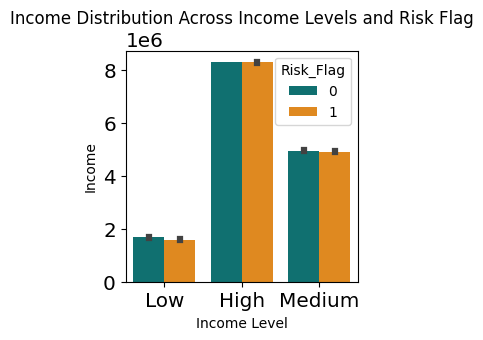

In [ ]:
plt.figure(figsize=(3, 3))
sns.barplot(x="Income_Level", y='Income', hue="Risk_Flag", data=df, palette=colors)
plt.title('Income Distribution Across Income Levels and Risk Flag')
plt.xlabel('Income Level')
plt.legend(title='Risk_Flag')
plt.show()

In [ ]:
chi_squared_test(df, cat1='Income_Level', cat2='Risk_Flag')

Income_Level and Risk_Flag
p value is 0.0006273726872426013
There is a significant relationship (dependency) between Income_Level and Risk_Flag
--------------------------------------


**Data Insight**

  Income_level memiliki korelasi dengan Risk_flag dan dapat menjadi alternatif pengganti income yang tidak berkorelasi dengan Risk_flag

### 2. Job Consistency

In [ ]:
df['Job_Consistency'] = df['Experience'] - df['CURRENT_JOB_YRS']

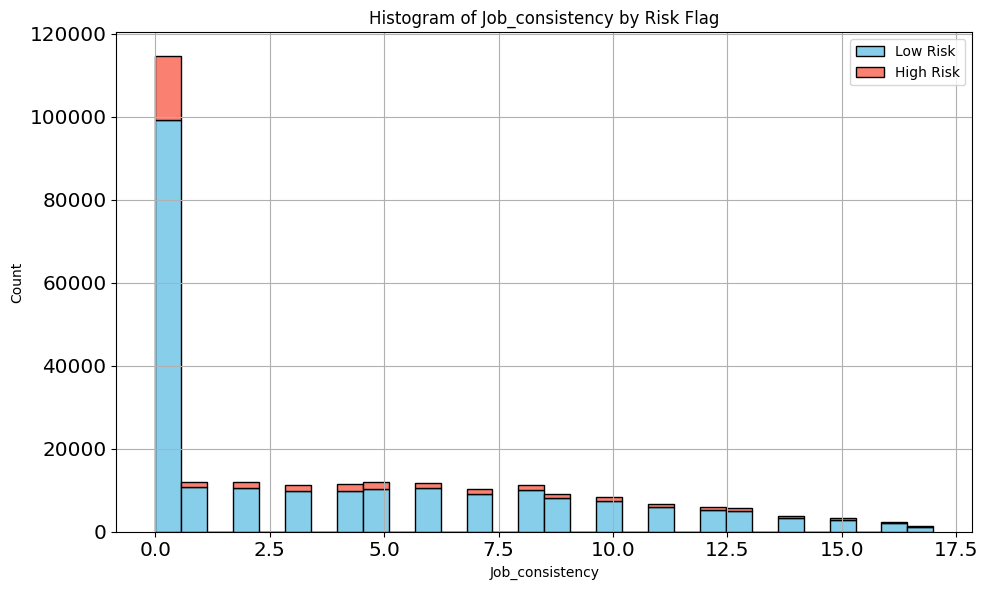

In [ ]:
feature = 'Job_Consistency'

# Split data by risk_flag
low_risk = df[df['Risk_Flag'] == 0][feature]
high_risk = df[df['Risk_Flag'] == 1][feature]

# Plot stacked histogram
plt.figure(figsize=(10, 6))
plt.hist([low_risk, high_risk], bins=30, stacked=True,
         label=['Low Risk', 'High Risk'], color=['skyblue', 'salmon'], edgecolor='black')

plt.xlabel(feature.capitalize())
plt.ylabel('Count')
plt.title(f'Histogram of {feature.capitalize()} by Risk Flag')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
compute_anova(df,nums='Job_Consistency',cats='Risk_Flag')

Anova : Job_Consistency and Risk_Flag
F-statistic: 253.55368928048821, P-value: 4.651824889241186e-57
Job_Consistency among Risk_Flag's 2 categories are significantly different
--------------------------------------


**Data Insight**

  Kedua feature engineering baru memiliki korelasi dengan target Risk_Flag.

# Feature Encoding

### One-Hot Encoding

In [ ]:
One_hot = ['Car_Ownership', 'Married/Single', 'House_Ownership']
for cat in One_hot:
    dummies = pd.get_dummies(df[cat], prefix=cat, drop_first=True)
    df = pd.concat([df, dummies], axis=1)

df.drop(columns=One_hot, inplace=True)

### Label Encoder

In [ ]:
df['Income_Level'] = df['Income_Level'].map({'High': 2, 'Medium': 1, 'Low': 0})

### Heatmap

<Axes: >

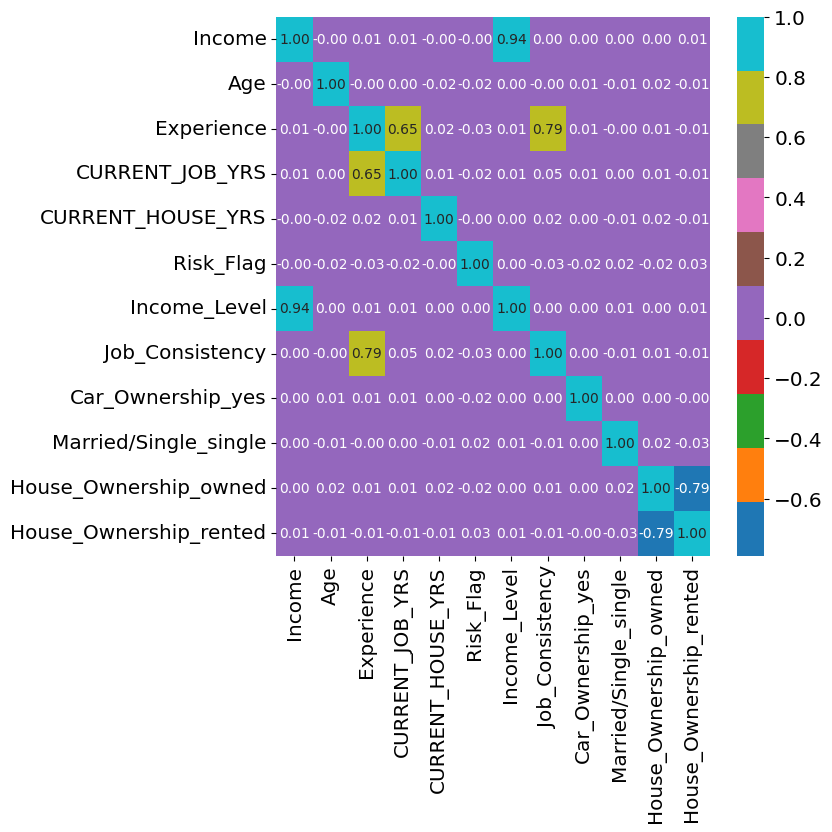

In [ ]:
plt.figure(figsize=(7, 7))
sns.heatmap(df.select_dtypes(include=['int','bool']).corr(), cmap='tab10', annot=True, fmt='.2f')

In [ ]:
# drop unnecessary
df.drop(['Id','Income'], axis=1, inplace=True)

Drop data dengan multicollinearity yang tinggi

# Split Data

In [ ]:
features = df.select_dtypes(["float64", "int64", "boolean"]).columns
X = df[features].drop(['Risk_Flag'], axis=1)
y = df['Risk_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

In [ ]:
nums = df.select_dtypes(["float64", "int64"]).columns
nums = nums.drop('Risk_Flag')
for col in nums:
    iqr_outliers = detect_outliers_iqr(df, col)

    if not iqr_outliers.empty:
        print(f"Outliers detected in {col}:")
        print(iqr_outliers[['Id', col]])  # Adjust columns based on your dataset
        print("\n" + "-"*50 + "\n")  # Separator for better readability
    else:
        print(f"No outliers detected in {col}\n")

No outliers detected in Age

No outliers detected in Experience

No outliers detected in CURRENT_JOB_YRS

No outliers detected in CURRENT_HOUSE_YRS

No outliers detected in Income_Level

No outliers detected in Job_Consistency



In [ ]:
print(f'Jumlah baris sebelum memfilter outlier: {len(X_train)}')

numeric_cols = X_train.select_dtypes(include=["float64", "int64"]).columns
X_train_numeric = X_train[numeric_cols]

Q1 = X_train_numeric.quantile(0.25)
Q3 = X_train_numeric.quantile(0.75)
IQR = Q3 - Q1

filtered = ~((X_train_numeric < (Q1 - 1.5 * IQR)) | (X_train_numeric > (Q3 + 1.5 * IQR))).any(axis=1)

# Apply the filter to full X_train and y_train
X_train = X_train[filtered]
y_train = y_train[filtered]

print(f'Jumlah baris setelah memfilter outlier: {len(X_train)}')

Jumlah baris sebelum memfilter outlier: 176400
Jumlah baris setelah memfilter outlier: 176400


**Data Insight**

  Tidak terdapat outliers pada data.

# Scaling

In [ ]:
X_train

,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Income_Level,Job_Consistency,Car_Ownership_yes,Married/Single_single,House_Ownership_owned,House_Ownership_rented
8166,40,12,11,11,1,1,True,True,False,True
84279,72,1,1,11,1,0,False,True,False,True
37928,26,5,3,14,1,2,False,True,False,True
153707,79,15,13,13,2,2,False,False,False,True
63484,31,20,7,12,1,13,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...
119879,59,1,1,12,0,0,True,True,False,True
103694,51,20,7,10,2,13,False,False,False,True
131932,25,5,5,10,2,0,False,True,False,True
146867,40,2,2,14,2,0,True,True,False,True


In [ ]:
# List of numerical features
new_nums = ['Age', 'Experience','CURRENT_JOB_YRS','CURRENT_HOUSE_YRS','Income_Level','Job_Consistency']

scaler = StandardScaler()

# Fit the scaler on the entire X_train
X_train[new_nums] = scaler.fit_transform(X_train[new_nums])
# Use the same scaler to X_test
X_test[new_nums] = scaler.transform(X_test[new_nums])

In [ ]:
X_train

,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Income_Level,Job_Consistency,Car_Ownership_yes,Married/Single_single,House_Ownership_owned,House_Ownership_rented
8166,-0.586987,0.318934,1.278795,-0.711856,-0.011580,-0.599734,True,True,False,True
84279,1.287031,-1.513169,-1.460538,-0.711856,-0.011580,-0.817551,False,True,False,True
37928,-1.406870,-0.846950,-0.912672,1.432220,-0.011580,-0.381917,False,True,False,True
153707,1.696973,0.818598,1.826662,0.717528,1.209427,-0.381917,False,False,False,True
63484,-1.114055,1.651372,0.183062,0.002836,-0.011580,2.014071,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...
119879,0.525711,-1.513169,-1.460538,0.002836,-1.232587,-0.817551,True,True,False,True
103694,0.057207,1.651372,0.183062,-1.426547,1.209427,2.014071,False,False,False,True
131932,-1.465433,-0.846950,-0.364805,-1.426547,1.209427,-0.817551,False,True,False,True
146867,-0.586987,-1.346615,-1.186605,1.432220,1.209427,-0.817551,True,True,False,True


# Class Imbalance

In [ ]:
df['Risk_Flag'].value_counts(normalize=True)

,proportion
Risk_Flag,
0,0.877
1,0.123


### UnderSampling

In [ ]:
X_train.shape

(176400, 10)

In [ ]:
rus = RandomUnderSampler(random_state=42)

X_train, y_train = rus.fit_resample(X_train, y_train)

In [ ]:
y_train.value_counts(normalize=True)

,proportion
Risk_Flag,
0,0.5
1,0.5


In [ ]:
X_train.shape

(43450, 10)

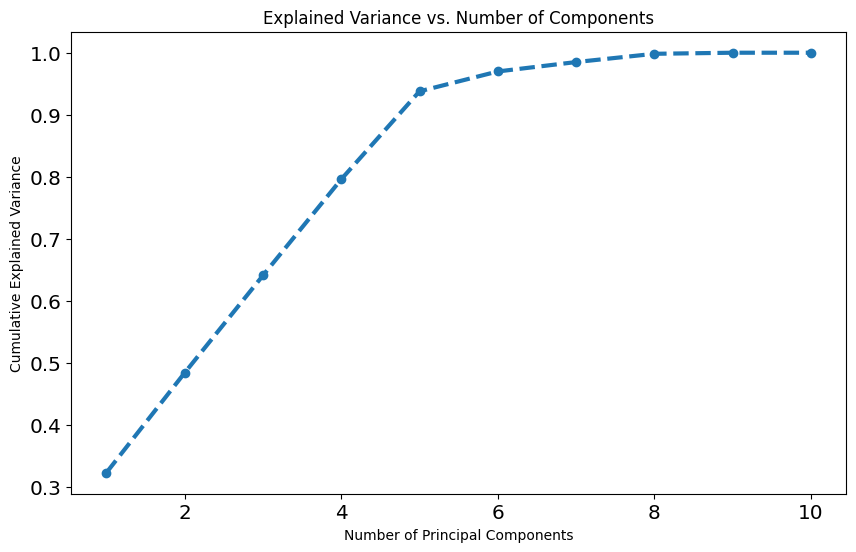

In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_train)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = explained_variance_ratio.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.show()

In [ ]:
pca = PCA(n_components=8)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# Modeling

Pemilihan recall karena pada kasus loan predict, menghindari false negative (yaitu diprediksi "low risk" padahal sebenarnya "high risk"). Memberikan peminjam yang sebenarnya berisiko tinggi gagal bayar dapat berdampak pada kerugian finansial langsung, dan bisa sangat besar apabila ajuan pinjamannya besar. Menolak pinjaman dari customer yang sebenarnya "tidak berisiko", dampaknya lebih ringan, karena hanya menyebabkan kehilangan potensi keuntungan (opportunity loss), bukan kerugian langsung.


In [ ]:
def eval_classification(model, model_name, threshold=0.4):
    model.fit(X_train, y_train)

    metrics = {"Model": model_name}

    # Predictions
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    # Basic metrics
    metrics["Recall Train"] = recall_score(y_train, y_pred_train)
    metrics["Recall Test"] = recall_score(y_test, y_pred_test)
    metrics["F1 Train"] = f1_score(y_train, y_pred_train)
    metrics["F1 Test"] = f1_score(y_test, y_pred_test)

    # Thresholded predictions using predict_proba
    if hasattr(model, "predict_proba"):
        y_proba_train = model.predict_proba(X_train)[:, 1]
        y_proba_test = model.predict_proba(X_test)[:, 1]

        y_pred_thresh_train = (y_proba_train >= threshold).astype(int)
        y_pred_thresh_test = (y_proba_test >= threshold).astype(int)

        metrics["Recall Train (proba)"] = recall_score(y_train, y_pred_thresh_train)
        metrics["Recall Test (proba)"] = recall_score(y_test, y_pred_thresh_test)

    # Cross-validation
    score = cross_validate(model, X, y, cv=5, scoring='recall', return_train_score=True)
    metrics["Recall CV Train"] = score['train_score'].mean()
    metrics["Recall CV Test"] = score['test_score'].mean()

    return metrics

In [ ]:
def show_feature_importance(model):
    # Get the names of the original features before PCA
    original_features = X.columns.tolist()

    # Number of PCA components
    num_components = X_train.shape[1]

    # Create column names based on PCA components, but with original feature names as prefix
    pca_column_names = [f'{original_features[i]}_PC{i+1}' for i in range(min(num_components, len(original_features)))]
    # Add additional PCA columns if num_components > len(original_features)
    pca_column_names += [f'PC{i+1}' for i in range(len(original_features), num_components)]


    # Use the created column names
    feat_importances = pd.Series(model.feature_importances_, index=pca_column_names)

    # Sort feature importances in descending order
    feat_importances = feat_importances.sort_values(ascending=False)

    # Create a colorful bar plot with soft colors using seaborn palette and colormap
    sns.set_palette("pastel")
    num_colors = len(feat_importances)
    colors = sns.color_palette("pastel", num_colors)
    ax = feat_importances.plot(kind='barh', figsize=(10, 8), color=colors)
    ax.invert_yaxis()

    plt.xlabel('Score')
    plt.ylabel('Feature')
    plt.title('Feature Importance Score')

    plt.show()

def show_best_hyperparameter(model):
    print(model.best_estimator_.get_params())

In [ ]:
results = []

models = {
    "LogisticRegression" : LogisticRegression(),
    "DecisionTreeClassifier" : DecisionTreeClassifier(),
    "RandomForest" : RandomForestClassifier(),
    "XGB" : XGBClassifier(),
    "Gaussian" : GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "AdaBoost" : AdaBoostClassifier(),
    "Ridge": RidgeClassifier(),
    "SGD": SGDClassifier(),
    "PassiveAggressive": PassiveAggressiveClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "HistGradientBoosting": HistGradientBoostingClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "LightGBM": LGBMClassifier(verbosity=-1),
    "CatBoost": CatBoostClassifier(verbose=False),
    "MLP" : MLPClassifier()
}

for name, model in models.items():
    metrics = eval_classification(model, model_name=name)
    results.append(metrics)

df_results = pd.DataFrame(results)
display(df_results.round(3))

,Model,Recall Train,Recall Test,F1 Train,F1 Test,Recall Train (proba),Recall Test (proba),Recall CV Train,Recall CV Test
0,LogisticRegression,0.567,0.569,0.549,0.222,0.984,0.986,0.000,0.000
1,DecisionTreeClassifier,0.985,0.867,0.948,0.575,0.992,0.872,0.711,0.556
2,RandomForest,0.988,0.841,0.948,0.589,0.992,0.887,0.733,0.525
3,XGB,0.872,0.826,0.865,0.529,0.933,0.884,0.120,0.099
4,Gaussian,0.769,0.770,0.624,0.228,0.858,0.861,0.000,0.000
5,KNN,0.787,0.768,0.828,0.527,0.895,0.855,0.618,0.590
6,AdaBoost,0.536,0.535,0.542,0.227,0.904,0.906,0.000,0.000
7,Ridge,0.565,0.568,0.548,0.222,NaN,NaN,0.000,0.000
8,SGD,0.683,0.691,0.591,0.223,NaN,NaN,0.000,0.000
9,PassiveAggressive,0.279,0.294,0.368,0.195,NaN,NaN,0.201,0.201


# Random Forest

## Base Model

In [ ]:
rf_model = RandomForestClassifier()

print(f'Evaluate model: RandomForestClassifier sebelum tuning')
eval_classification_single(rf_model)

Evaluate model: RandomForestClassifier sebelum tuning
Recall (Train Set): 0.99
Recall (Test Set): 0.84
F1-Score (Train Set): 0.95
F1-Score (Test Set): 0.59
recall (train-proba): 0.99
recall (test-proba): 0.89


In [ ]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

## Hyperparameter Tuning

### Learning Curve n_estimators

In [ ]:
def draw_learning_curve(param_values):
    train_scores = []
    test_scores = []

    for n in param_values:
        model = RandomForestClassifier(n_estimators=n)
        model.fit(X_train, y_train)

        # Apply custom threshold
        threshold = 0.4

        # eval on train
        y_pred_proba_train = model.predict_proba(X_train)
        y_pred_thresh_train = (y_pred_proba_train[:, 1] >= threshold).astype(int)
        train_recall = recall_score(y_train, y_pred_thresh_train)
        train_scores.append(train_recall)

        # eval on test
        y_pred_proba = model.predict_proba(X_test)
        y_pred_thresh = (y_pred_proba[:, 1] >= threshold).astype(int)
        test_recall = recall_score(y_test, y_pred_thresh)
        test_scores.append(test_recall)

        print('param value: ' + str(n) + '; train: ' + str(train_recall) + '; test: '+ str(test_recall))


    plt.plot(param_values, train_scores, label='Train')
    plt.plot(param_values, test_scores, label='Test')
    plt.xlabel('n_estimators')
    plt.ylabel('Recall')
    plt.title('Learning Curve - Hyperparameter n_estimators - RandomForestClassifier')
    plt.legend()
    plt.show()

param value: 2; train: 0.9878020713463751; test: 0.9150037752130299
param value: 112; train: 1.0; test: 0.8877143781684823
param value: 223; train: 1.0; test: 0.8881458310861827
param value: 334; train: 0.9998158803222095; test: 0.8877143781684823
param value: 445; train: 0.9998158803222095; test: 0.8881458310861827
param value: 556; train: 1.0; test: 0.8868514723330817
param value: 667; train: 1.0; test: 0.888577284003883
param value: 778; train: 1.0; test: 0.8882536943156079
param value: 889; train: 0.9998158803222095; test: 0.8878222413979074
param value: 1000; train: 1.0; test: 0.887282925250782


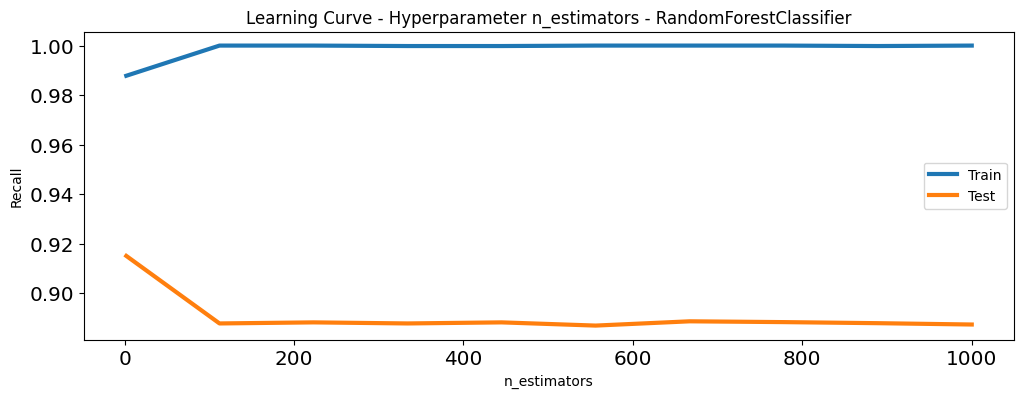

In [ ]:
n_estimators = [int(x)for x in np.linspace(2,1000,10)]
draw_learning_curve(n_estimators)

param value: 2; train: 0.9862370540851554; test: 0.910257793118326
param value: 12; train: 0.9993095512082854; test: 0.8949412145399633
param value: 22; train: 0.9997698504027618; test: 0.894617624851688
param value: 33; train: 0.9998158803222095; test: 0.8894401898392837
param value: 43; train: 1.0; test: 0.8864200194153813
param value: 54; train: 1.0; test: 0.8883615575450329
param value: 64; train: 1.0; test: 0.8871750620213569
param value: 74; train: 1.0; test: 0.8881458310861827
param value: 85; train: 1.0; test: 0.8880379678567576
param value: 95; train: 0.9998158803222095; test: 0.8868514723330817
param value: 106; train: 1.0; test: 0.8876065149390573
param value: 116; train: 0.9998158803222095; test: 0.8887930104627333
param value: 127; train: 0.9998158803222095; test: 0.8863121561859562
param value: 137; train: 1.0; test: 0.8891166001510086
param value: 147; train: 1.0; test: 0.889655916298134
param value: 158; train: 0.9998158803222095; test: 0.8850177974328551
param value: 1

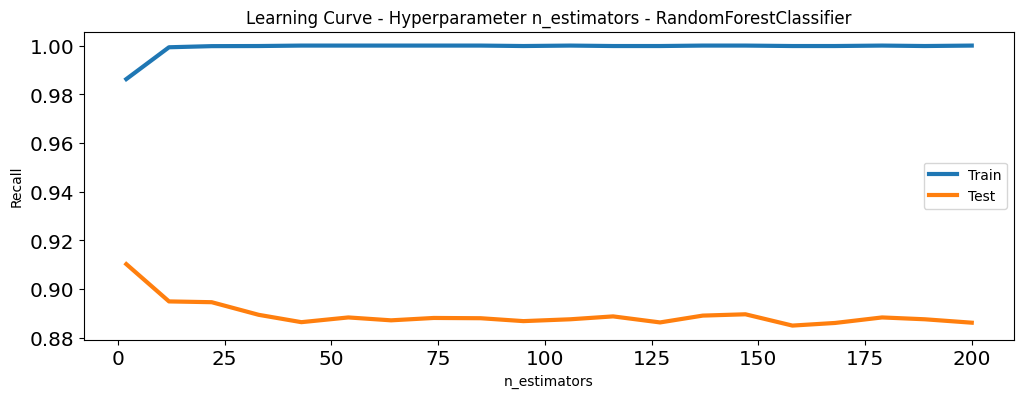

In [ ]:
n_estimators = [int(x)for x in np.linspace(2,200,20)]
draw_learning_curve(n_estimators)

n_estimators = 2

### Learning Curve max_depth

In [ ]:
def draw_learning_curve_max_depth(param_values):
    train_scores = []
    test_scores = []

    for n in param_values:
        model = RandomForestClassifier(random_state=42, n_estimators=2, max_depth=n)
        model.fit(X_train, y_train)

        # Apply custom threshold
        threshold = 0.4

        # eval on train
        y_pred_proba_train = model.predict_proba(X_train)
        y_pred_thresh_train = (y_pred_proba_train[:, 1] >= threshold).astype(int)
        train_recall = recall_score(y_train, y_pred_thresh_train)
        train_scores.append(train_recall)

        # eval on test
        y_pred_proba = model.predict_proba(X_test)
        y_pred_thresh = (y_pred_proba[:, 1] >= threshold).astype(int)
        test_recall = recall_score(y_test, y_pred_thresh)
        test_scores.append(test_recall)

        print('param value: ' + str(n) + '; train: ' + str(train_recall) + '; test: '+ str(test_recall))

    plt.plot(param_values, train_scores, label='Train')
    plt.plot(param_values, test_scores, label='Test')
    plt.xlabel('max_depth')
    plt.ylabel('Recall')
    plt.title('Learning Curve - Hyperparameter max_depth - RandomForestClassifier')
    plt.legend()
    plt.show()

param value: 2; train: 1.0; test: 1.0
param value: 12; train: 0.9262600690448791; test: 0.8992557437169669
param value: 22; train: 0.9610126582278481; test: 0.8987164275698415
param value: 33; train: 0.9747756041426927; test: 0.9009815553877684
param value: 43; train: 0.9883544303797468; test: 0.9118757415597023
param value: 54; train: 0.9885385500575374; test: 0.9134936900010786
param value: 64; train: 0.9885385500575374; test: 0.9134936900010786
param value: 74; train: 0.9885385500575374; test: 0.9134936900010786
param value: 85; train: 0.9885385500575374; test: 0.9134936900010786
param value: 95; train: 0.9885385500575374; test: 0.9134936900010786
param value: 106; train: 0.9885385500575374; test: 0.9134936900010786
param value: 116; train: 0.9885385500575374; test: 0.9134936900010786
param value: 127; train: 0.9885385500575374; test: 0.9134936900010786
param value: 137; train: 0.9885385500575374; test: 0.9134936900010786
param value: 147; train: 0.9885385500575374; test: 0.91349369

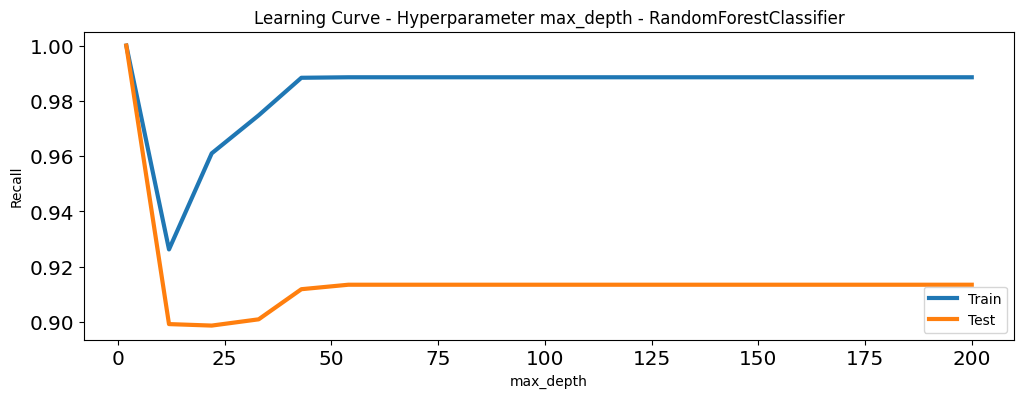

In [ ]:
max_depth = [int(x)for x in np.linspace(2,200,20)]
draw_learning_curve_max_depth(max_depth)

param value: 1; train: 1.0; test: 1.0
param value: 6; train: 0.970126582278481; test: 0.9649444504368461
param value: 11; train: 0.9498273878020713; test: 0.9269765936792148
param value: 16; train: 0.9568699654775604; test: 0.9213677057491101
param value: 21; train: 0.9679171461449942; test: 0.9007658289289181
param value: 27; train: 0.9785040276179516; test: 0.9068061697767231
param value: 32; train: 0.9866973532796317; test: 0.917592492719232
param value: 37; train: 0.9881703107019563; test: 0.9128465106245282
param value: 42; train: 0.988078250863061; test: 0.9107971092654514
param value: 47; train: 0.9881703107019563; test: 0.9123071944774026
param value: 53; train: 0.9885385500575374; test: 0.9134936900010786
param value: 58; train: 0.9885385500575374; test: 0.9134936900010786
param value: 63; train: 0.9885385500575374; test: 0.9134936900010786
param value: 68; train: 0.9885385500575374; test: 0.9134936900010786
param value: 73; train: 0.9885385500575374; test: 0.9134936900010786


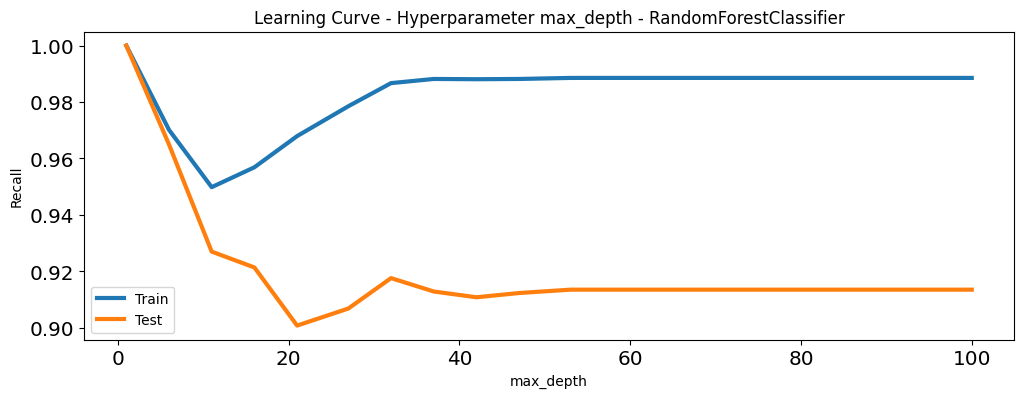

In [ ]:
max_depth = [int(x)for x in np.linspace(1,100,20)]
draw_learning_curve_max_depth(max_depth)

max_depth = 16

### Learning Curve min_samples_split

In [ ]:
def draw_learning_curve_min_samples_split(param_values):
    train_scores = []
    test_scores = []

    for n in param_values:
        model = RandomForestClassifier(n_estimators=2, max_depth=16, min_samples_split=n, random_state=42)
        model.fit(X_train, y_train)

        # Apply custom threshold
        threshold = 0.4

        # eval on train
        y_pred_proba_train = model.predict_proba(X_train)
        y_pred_thresh_train = (y_pred_proba_train[:, 1] >= threshold).astype(int)
        train_recall = recall_score(y_train, y_pred_thresh_train)
        train_scores.append(train_recall)

        # eval on test
        y_pred_proba = model.predict_proba(X_test)
        y_pred_thresh = (y_pred_proba[:, 1] >= threshold).astype(int)
        test_recall = recall_score(y_test, y_pred_thresh)
        test_scores.append(test_recall)

        print('param value: ' + str(n) + '; train: ' + str(train_recall) + '; test: '+ str(test_recall))

    plt.plot(param_values, train_scores, label='Train')
    plt.plot(param_values, test_scores, label='Test')
    plt.xlabel('min_samples_split')
    plt.ylabel('Recall')
    plt.title('Learning Curve - Hyperparameter min_samples_split - RandomForestClassifier')
    plt.legend()
    plt.show()

param value: 2; train: 0.9568699654775604; test: 0.9213677057491101
param value: 112; train: 0.8992405063291139; test: 0.8839391651386043
param value: 223; train: 0.8879631760644419; test: 0.8713191672958689
param value: 334; train: 0.8972151898734178; test: 0.8858807032682559
param value: 445; train: 0.8971691599539701; test: 0.884802070974005
param value: 556; train: 0.9068814729574223; test: 0.8996871966346672
param value: 667; train: 0.9090909090909091; test: 0.9002265127817927
param value: 778; train: 0.9136018411967779; test: 0.9082083917592493
param value: 889; train: 0.9165017261219793; test: 0.916405997195556
param value: 1000; train: 0.8929804372842347; test: 0.8832919857620537


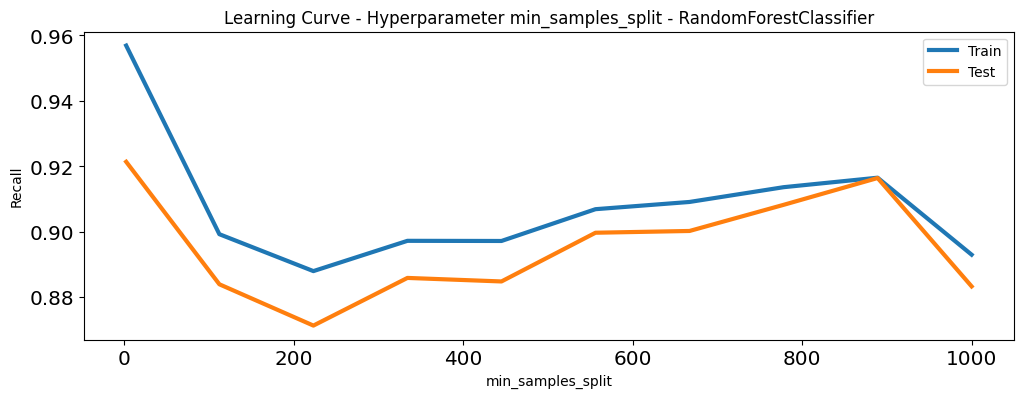

In [ ]:
min_samples_split = [int(x)for x in np.linspace(2,1000,10)]
draw_learning_curve_min_samples_split(min_samples_split)

param value: 800; train: 0.9138319907940161; test: 0.9072376226944234
param value: 814; train: 0.9021864211737629; test: 0.8915974544277856
param value: 828; train: 0.9066052934407365; test: 0.8988242907992665
param value: 842; train: 0.9153049482163407; test: 0.9099342034300507
param value: 857; train: 0.9154430379746835; test: 0.9101499298889009
param value: 871; train: 0.922945914844649; test: 0.9196418940783087
param value: 885; train: 0.9165017261219793; test: 0.916405997195556
param value: 900; train: 0.9165017261219793; test: 0.916405997195556
param value: 914; train: 0.9142002301495973; test: 0.9130622370833783
param value: 928; train: 0.9141081703107019; test: 0.9124150577068277
param value: 942; train: 0.9285155350978136; test: 0.9264372775320893
param value: 957; train: 0.9231300345224396; test: 0.9141408693776292
param value: 971; train: 0.9231300345224396; test: 0.9141408693776292
param value: 985; train: 0.8866283084004603; test: 0.8764966023082731
param value: 1000; trai

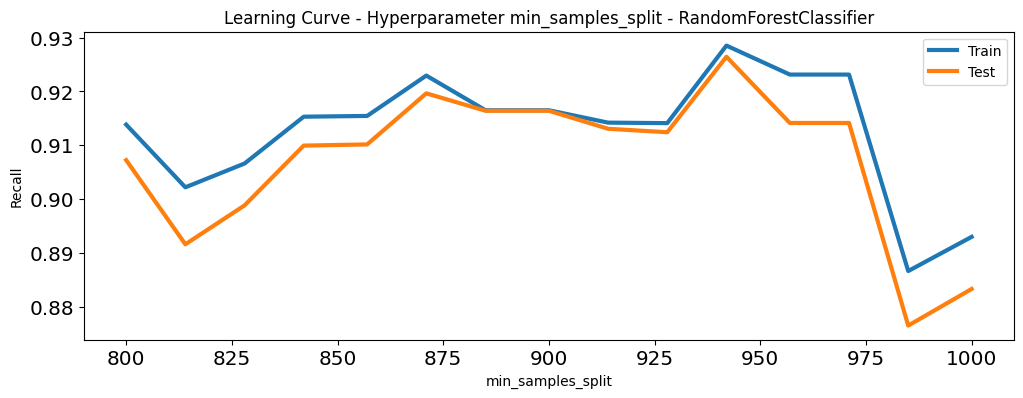

In [ ]:
min_samples_split = [int(x)for x in np.linspace(800,1000,15)]
draw_learning_curve_min_samples_split(min_samples_split)

min_samples_split = 942

### Learning Curve min_samples_leaf


In [ ]:
def draw_learning_curve_min_samples_leaf(param_values):
    train_scores = []
    test_scores = []

    for n in param_values:
        model = RandomForestClassifier(n_estimators=2, max_depth=106, min_samples_split=942,min_samples_leaf=n)
        model.fit(X_train, y_train)

        # Apply custom threshold
        threshold = 0.4

        # eval on train
        y_pred_proba_train = model.predict_proba(X_train)
        y_pred_thresh_train = (y_pred_proba_train[:, 1] >= threshold).astype(int)
        train_recall = recall_score(y_train, y_pred_thresh_train)
        train_scores.append(train_recall)

        # eval on test
        y_pred_proba = model.predict_proba(X_test)
        y_pred_thresh = (y_pred_proba[:, 1] >= threshold).astype(int)
        test_recall = recall_score(y_test, y_pred_thresh)
        test_scores.append(test_recall)

        print('param value: ' + str(n) + '; train: ' + str(train_recall) + '; test: '+ str(test_recall))

    plt.plot(param_values, train_scores, label='Train')
    plt.plot(param_values, test_scores, label='Test')
    plt.xlabel('min_samples_leaf')
    plt.ylabel('Recall')
    plt.title('Learning Curve - Hyperparameter min_samples_leaf - RandomForestClassifier')
    plt.legend()
    plt.show()

param value: 2; train: 0.8897583429228999; test: 0.8767123287671232
param value: 112; train: 0.91512082853855; test: 0.9079926653003991
param value: 223; train: 0.891783659378596; test: 0.8829683960737784
param value: 334; train: 0.9041657077100115; test: 0.9015208715348938
param value: 445; train: 0.9094591484464902; test: 0.9074533491532737
param value: 556; train: 0.9444418872266973; test: 0.9415381296516018
param value: 667; train: 0.9357882623705408; test: 0.9384100959982742
param value: 778; train: 0.9804833141542002; test: 0.9785352173444073
param value: 889; train: 0.9450402761795167; test: 0.9455290691403301
param value: 1000; train: 0.9675949367088608; test: 0.9689353899255744


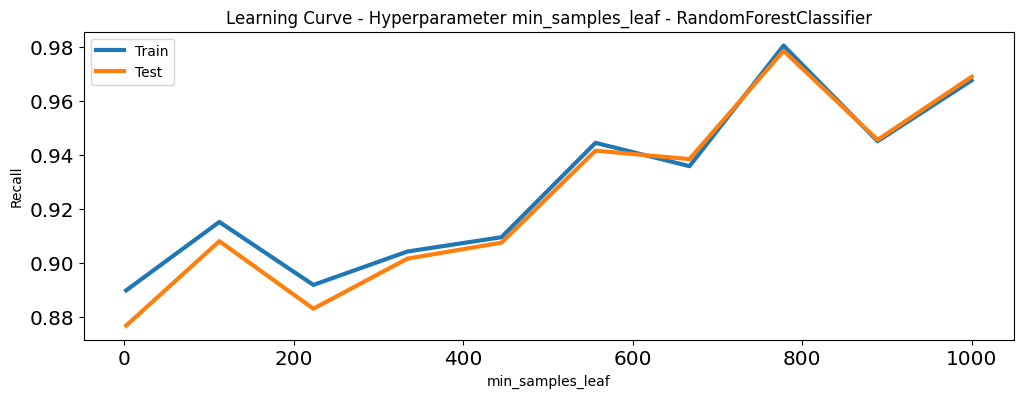

In [ ]:
min_samples_leaf = [int(x)for x in np.linspace(2,1000,10)]
draw_learning_curve_min_samples_leaf(min_samples_leaf)

param value: 680; train: 0.9550747986191024; test: 0.9532952216589364
param value: 702; train: 0.961288837744534; test: 0.9586883831301909
param value: 725; train: 0.9530494821634062; test: 0.949088555711358
param value: 748; train: 0.9641426927502876; test: 0.9645129975191458
param value: 771; train: 0.9628538550057537; test: 0.959982741883292
param value: 794; train: 0.9839355581127733; test: 0.9847912846510625
param value: 817; train: 0.9748676639815881; test: 0.9728184661848776
param value: 840; train: 0.9514844649021864; test: 0.947794196958257
param value: 862; train: 0.9785040276179516; test: 0.9756229101499299
param value: 885; train: 0.967180667433832; test: 0.9650523136662712
param value: 908; train: 0.9851783659378596; test: 0.9843598317333621
param value: 931; train: 0.9905638665132336; test: 0.9898608564340416
param value: 954; train: 0.9662140391254316; test: 0.9635422284543199
param value: 977; train: 0.9686536248561565; test: 0.9694747060726998
param value: 1000; train:

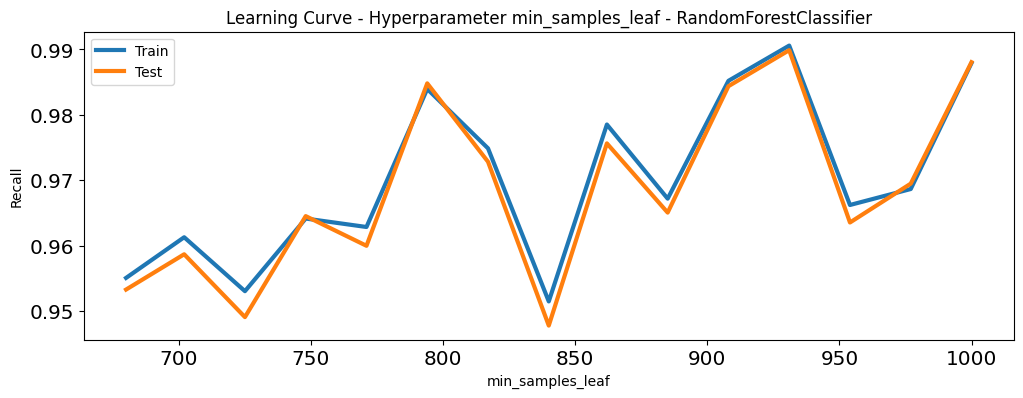

In [ ]:
min_samples_leaf = [int(x)for x in np.linspace(680,1000,15)]
draw_learning_curve_min_samples_leaf(min_samples_leaf)

## Randomized CV

In [ ]:
def eval_classification_single(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    print("Recall (Train Set): %.2f" % recall_score(y_train, y_pred_train))
    print("Recall (Test Set): %.2f" % recall_score(y_test, y_pred))

    print("F1-Score (Train Set): %.2f" % f1_score(y_train, y_pred_train))
    print("F1-Score (Test Set): %.2f" % f1_score(y_test, y_pred))

    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)
        y_pred_proba_train = model.predict_proba(X_train)

        # Apply custom threshold (e.g., 0.3)
        threshold = 0.4
        y_pred_thresh = (y_pred_proba[:, 1] >= threshold).astype(int)
        y_pred_thresh_train = (y_pred_proba_train[:, 1] >= threshold).astype(int)

        # Evaluate based on the thresholded predictions
        print("recall (train-proba): %.2f" % recall_score(y_train, y_pred_thresh_train))
        print("recall (test-proba): %.2f" % recall_score(y_test, y_pred_thresh))

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [1, 2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_random = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf_random,
    param_distributions=param_grid,
    n_iter=50,  # number of random combos to try
    scoring="recall",  # prioritize catching risky loans
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

print(f'Evaluate model: RandomForestClassifier')
eval_classification_single(random_search)

Evaluate model: RandomForestClassifier
Recall (Train Set): 0.99
Recall (Test Set): 0.85
F1-Score (Train Set): 0.95
F1-Score (Test Set): 0.58
recall (train-proba): 0.99
recall (test-proba): 0.90


In [ ]:
# Get the names of the original features before PCA
original_features = X.columns.tolist()

# Number of PCA components
num_components = X_train.shape[1]

# Create column names based on PCA components, but with original feature names as prefix
pca_column_names = [f'{original_features[i]}_PC{i+1}' for i in range(min(num_components, len(original_features)))]
# Add additional PCA columns if num_components > len(original_features)
pca_column_names += [f'PC{i+1}' for i in range(len(original_features), num_components)]

X_train_col = pd.DataFrame(X_train, columns=pca_column_names)
X_test_col = pd.DataFrame(X_test, columns=pca_column_names)
features_important = pd.DataFrame({'Feature': X_train_col.columns.tolist(),
                                      'Value': list(random_search.best_estimator_.feature_importances_)})
features_important = features_important.sort_values('Value', ascending=False)
features_important

,Feature,Value
0,Age_PC1,0.137379
4,Income_Level_PC5,0.130340
5,Job_Consistency_PC6,0.126017
7,Married/Single_single_PC8,0.123766
1,Experience_PC2,0.123496
3,CURRENT_HOUSE_YRS_PC4,0.121048
6,Car_Ownership_yes_PC7,0.119779
2,CURRENT_JOB_YRS_PC3,0.118176


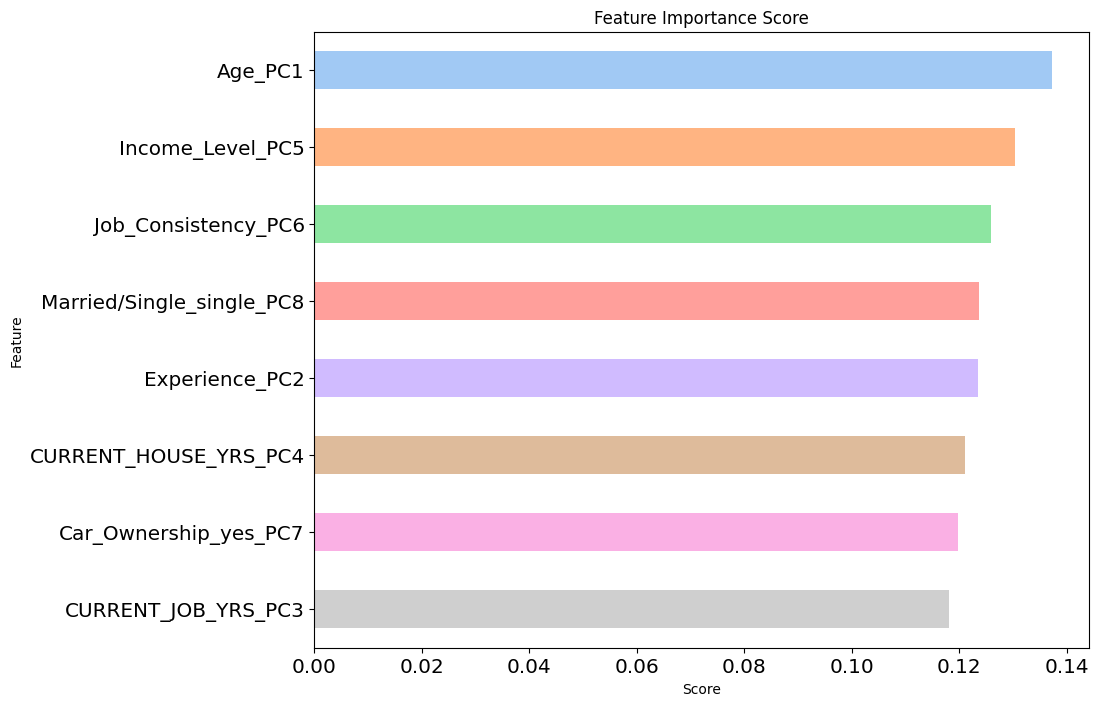

In [ ]:
show_feature_importance(random_search.best_estimator_)